<a href="https://colab.research.google.com/github/wlrjs1300-coder/AI_26/blob/main/07_01_%EC%9D%B8%EA%B3%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 딥러닝 계산을 하기 위한 라이브러리 TensorFlow 불러오기
import tensorflow as tf

# 실행할 때마다 결과가 달라지는 것을 막기 위해 랜덤값 기준을 고정
# 이렇게 하면 같은 코드 실행 시 항상 동일한 결과가 나오게 된다
tf.keras.utils.set_random_seed(42)

# GPU / CPU 환경 차이 때문에 생길 수 있는 미세한 계산 차이를 줄여
# 실험 결과가 항상 동일하게 나오도록 설정
tf.config.experimental.enable_op_determinism()

# TensorFlow 안에 포함된 딥러닝 도구인 Keras 불러오기
from tensorflow import keras

# 패션 MNIST 데이터셋 불러오기
# 이 데이터는 28x28 픽셀의 흑백 이미지로 된 패션 아이템 그림이다
# 예: 티셔츠, 바지, 신발 등

# load_data()는 데이터를 두 묶음으로 나누어 반환한다
# 1️⃣ train : 모델을 학습시키는 데이터
# 2️⃣ test : 학습이 끝난 모델을 평가하는 데이터

# input  → 이미지 데이터
# target → 이미지의 정답 라벨 (어떤 패션 아이템인지)

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
print(train_input.shape, train_target.shape) # 전달받은 데이터의 크기를 확인

(60000, 28, 28) (60000,)


In [3]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


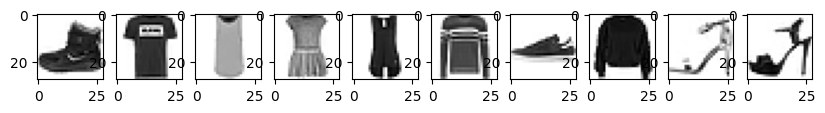

In [4]:
# 그래프와 이미지를 화면에 출력하기 위한 matplotlib 라이브러리 불러오기
import matplotlib.pyplot as plt

# 1행 10열의 이미지 출력 공간(그래프 판)을 생성
# figsize=(10,10)은 전체 출력 크기를 지정
fig, axs = plt.subplots(1, 10, figsize=(10,10))

# 처음 10개의 훈련 이미지를 반복하면서 출력
for i in range(10):

    # train_input에 있는 i번째 이미지를 화면에 출력
    # cmap='gray_r' 는 흑백 이미지 색상 설정 (MNIST 데이터는 흑백 이미지)
    axs[i].imshow(train_input[i], cmap='gray_r')

    # 축(axis)을 표시 (좌표 눈금 표시)
    axs[i].axis('on')

# 모든 이미지를 화면에 출력
plt.show()

# Fashion MNIST 데이터의 정답 라벨 의미
# 0 : 티셔츠 / 탑
# 1 : 바지
# 2 : 스웨터
# 3 : 드레스
# 4 : 코트
# 5 : 샌달
# 6 : 셔츠
# 7 : 스니커즈
# 8 : 가방
# 9 : 앵클부츠

In [5]:
print([train_target[i] for i in range(10)]) # 샘플 타깃 확인

[np.uint8(9), np.uint8(0), np.uint8(0), np.uint8(3), np.uint8(0), np.uint8(2), np.uint8(7), np.uint8(2), np.uint8(5), np.uint8(5)]


In [6]:
# 수치 계산을 위한 numpy 라이브러리 불러오기
import numpy as np

# train_target 안에 있는 값들의 종류와 개수를 확인
# np.unique()는 배열에서 중복을 제거하고 고유한 값만 반환하는 함수

# return_counts=True 옵션을 사용하면
# 각 값이 몇 번 등장했는지도 함께 반환한다
print(np.unique(train_target, return_counts=True))

# 출력 결과 설명
# 첫 번째 배열 → 데이터에 존재하는 라벨 종류 (0~9)
# 두 번째 배열 → 각 라벨이 몇 개씩 있는지

# Fashion MNIST 훈련 데이터는 총 60000개이고
# 10개의 클래스(옷 종류)가 동일하게 6000개씩 들어 있다

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


In [7]:
# 패션 이미지를 머신러닝 모델이 사용할 수 있도록 전처리하는 과정

# 이미지 픽셀 값은 0 ~ 255 사이의 정수로 이루어져 있음
# 값을 255로 나누어 0 ~ 1 사이의 값으로 변환 (정규화)
# 이렇게 하면 모델이 학습할 때 값의 크기 차이 때문에 생기는 문제를 줄일 수 있음
train_scaled = train_input / 255.0

# 원래 이미지 데이터는 (28, 28) 형태의 2차원 배열
# 머신러닝 모델은 1차원 특성 벡터를 입력으로 받기 때문에
# reshape()를 사용해 28×28 이미지를 784개의 값으로 펼침

# -1은 "자동으로 개수를 계산하라"는 의미
# 즉 전체 이미지 개수(60000)는 그대로 두고
# 각 이미지를 784개의 특성으로 변환
train_scaled = train_scaled.reshape(-1, 28*28)

# 변환된 데이터의 형태 확인
# 결과는 (60000, 784)
# → 60000개의 이미지
# → 각 이미지마다 784개의 픽셀 특성
print(train_scaled.shape)

(60000, 784)


In [8]:
# 모델의 성능을 평가하기 위한 교차검증 함수
from sklearn.model_selection import cross_validate

# 확률적 경사 하강법을 사용하는 분류 모델
from sklearn.linear_model import SGDClassifier

# SGD 분류기 생성
# loss='log_loss' → 로지스틱 회귀 방식으로 분류
# max_iter=5 → 전체 데이터를 5번 반복하며 학습 (에포크)
# random_state=42 → 실행할 때마다 같은 결과가 나오도록 랜덤값 고정
sc = SGDClassifier(loss='log_loss', max_iter=5, random_state=42)

# cross_validate()로 교차 검증 수행
# 데이터를 여러 부분으로 나누어
# 학습과 평가를 반복하면서 모델 성능을 확인

# sc           → 사용할 모델
# train_scaled → 입력 데이터 (이미지 픽셀)
# train_target → 정답 라벨 (패션 아이템 종류)
# n_jobs=-1    → 사용 가능한 모든 CPU 코어를 사용하여 병렬 처리
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)

# 교차 검증에서 나온 테스트 정확도를 평균내어 출력
# scores['test_score']에는 각 검증에서 나온 정확도가 저장됨
print(np.mean(scores['test_score']))

0.8194166666666666


In [ ]:
# 로지스틱 회귀 모델의 기본 아이디어 설명

# 예전에 배운 선형 회귀의 형태
# 여러 특성(feature)에 가중치를 곱하고 모두 더한 뒤 절편을 더해서 하나의 값을 계산
# z = a * (Weight) + b * (Length) + c * (Diagonal) + d * (Height) + e * (Width) + f

# Fashion MNIST에서는 입력 데이터가 물고기 길이 같은 특성이 아니라
# 이미지 픽셀 값(총 784개)이다.

# 예를 들어 "티셔츠 클래스"에 대한 점수를 계산하는 선형식은 다음과 같다.
# 각 픽셀 값에 가중치를 곱하고 모두 더한 뒤 절편을 더한다.

# z_티셔츠 = a * (픽셀1) + b * (픽셀2) + c * (픽셀3) + ... + e * (픽셀784) + f

# 하지만 바지를 판별하려면 티셔츠와 다른 기준이 필요하다.
# 따라서 바지 클래스는 별도의 가중치와 절편을 사용한다.

# z_바지 = a1 * (픽셀1) + b1 * (픽셀2) + c1 * (픽셀3) + ... + e1 * (픽셀784) + f1

# 같은 방식으로 나머지 패션 아이템에 대해서도 각각의 선형식을 만든다.
# Fashion MNIST에는 총 10개의 클래스가 있으므로
# 모델은 10개의 선형 방정식을 계산하게 된다.

# 계산된 10개의 값(z)은 아직 확률이 아니라 "점수(score)"이다.

# 이 점수들을 소프트맥스(softmax) 함수에 통과시키면
# 각 클래스에 대한 확률 값으로 변환된다.

# 예시 결과
# [티셔츠확률, 바지확률, 스웨터확률, 드레스확률, 코트확률,
#  샌달확률, 셔츠확률, 스니커즈확률, 가방확률, 앵클부츠확률]

# 가장 높은 확률을 가진 클래스를 최종 예측 결과로 선택한다.

# 클래스 번호 의미
# 0 : 티셔츠
# 1 : 바지
# 2 : 스웨터
# 3 : 드레스
# 4 : 코트
# 5 : 샌달
# 6 : 셔츠
# 7 : 스니커즈
# 8 : 가방
# 9 : 앵클부츠

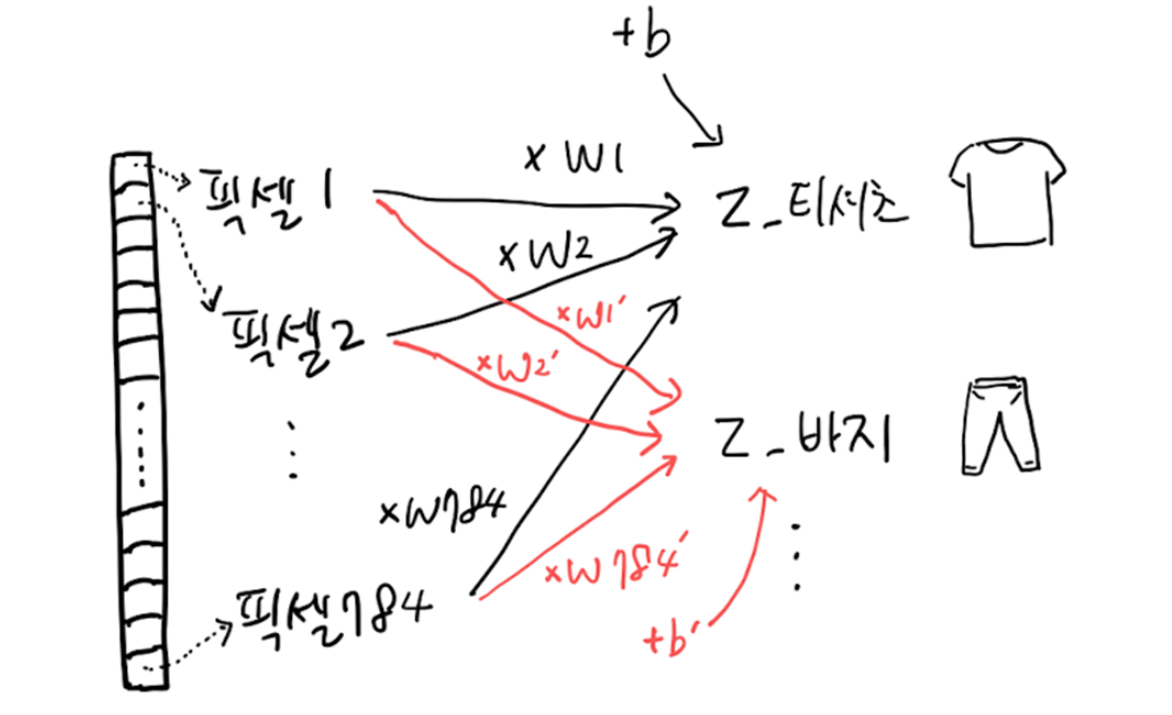

In [ ]:
# 인공신경망(Artificial Neural Network, ANN)을 이용하여
# 패션 아이템 분류 문제의 성능을 높이는 방법을 살펴본다.

# 패션 MNIST 문제에서는 총 10개의 클래스가 있다.
# (티셔츠, 바지, 스웨터, 드레스, 코트, 샌달, 셔츠, 스니커즈, 가방, 앵클부츠)

# 모델은 입력 이미지의 픽셀값을 이용해
# 각 클래스에 대한 점수(z 값)를 계산한다.

# 예를 들어
# z_티셔츠, z_바지, z_스웨터 ... z_앵클부츠
# 이렇게 총 10개의 z 값을 계산하게 된다.

# 이 z 값들은 신경망의 마지막 층에서 만들어지기 때문에
# 이를 출력층(Output Layer)이라고 부른다.

# 신경망에서 이런 선형 계산을 수행하는 하나의 계산 단위를
# 뉴런(Neuron) 또는 유닛(Unit)이라고 부른다.

# 입력 데이터는 이미지의 픽셀 값이다.
# Fashion MNIST 이미지 크기는 28×28이므로 총 784개의 픽셀이 존재한다.

# 이 784개의 입력값(x1 ~ x784)을 받는 층을
# 입력층(Input Layer)이라고 부른다.

# 각 입력 픽셀은 가중치(weight)와 곱해져서
# 출력 뉴런의 점수(z 값)를 계산하는데 사용된다.

# 예를 들어 첫 번째 클래스 점수는 다음과 같이 계산된다.
# z1 = w1.1*x1 + w1.2*x2 + ... + w1.784*x784 + b1

# 여기서 w는 가중치(weight), b는 절편(bias)이다.

# 출력 뉴런은 총 10개이므로
# 각각의 뉴런은 서로 다른 가중치를 가지고 점수를 계산한다.

# 여기서 말하는 "뉴런"은 사람의 뇌에 있는 뉴런과는 다르며
# 단순히 입력값을 계산하는 알고리즘적 계산 단위이다.

# 참고로 확률적 경사 하강법(SGD)을 사용한 로지스틱 회귀 모델은
# 구조적으로 보면 가장 단순한 형태의 인공신경망이라고 볼 수 있다.

# 즉 입력층(784) → 출력층(10) 구조의
# 가장 기본적인 신경망 모델이 바로 로지스틱 회귀 모델이다.

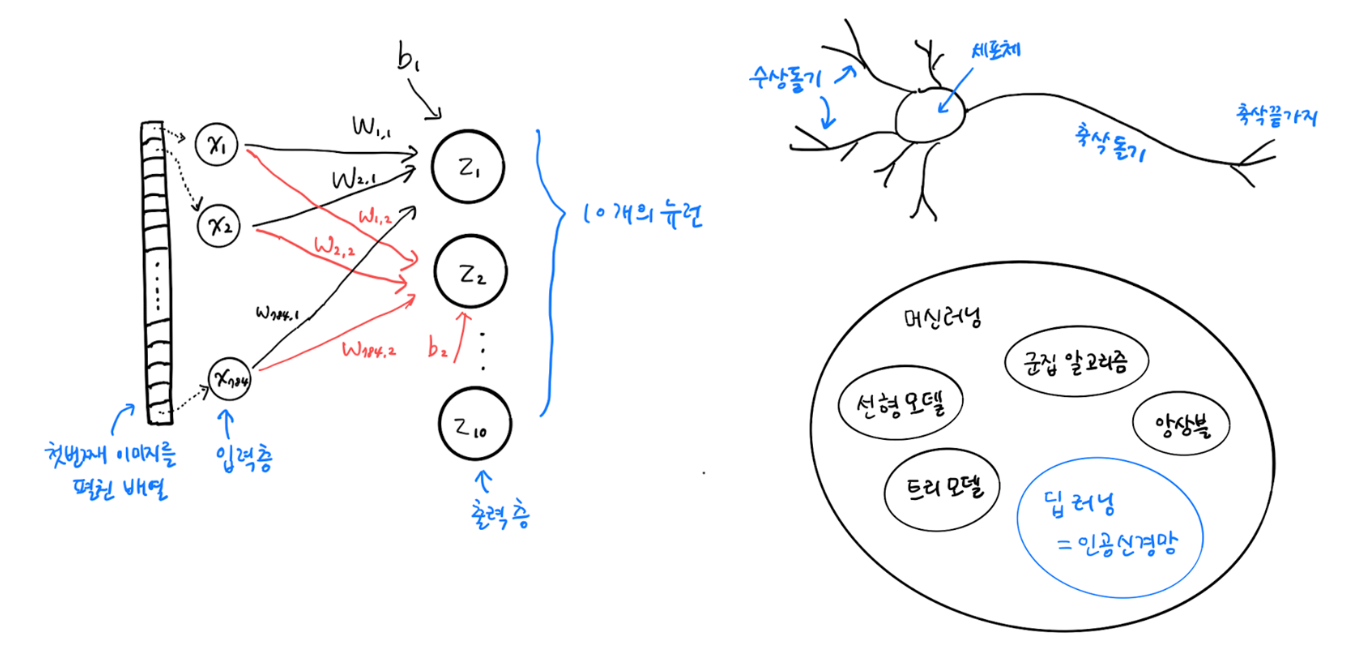

In [9]:
# 딥러닝 모델을 만들기 위해 TensorFlow 라이브러리를 사용한다.

# TensorFlow
# 구글이 개발한 딥러닝 및 머신러닝 라이브러리로
# 2015년에 오픈소스로 공개되었다.
# 대규모 행렬 계산을 효율적으로 처리할 수 있어
# 인공신경망과 같은 딥러닝 모델 구현에 널리 사용된다.

# TensorFlow는 알파고(AlphaGo) 프로젝트에서도 사용되면서
# 크게 유명해졌다. (이세돌 vs 알파고 대국 시기)

# TensorFlow 2.x 버전은 2019년에 공개되었으며
# 사용하기 쉽도록 구조가 많이 개선되었다.

# TensorFlow 라이브러리 불러오기
import tensorflow as tf

# TensorFlow 안에 포함된 고수준 API인 Keras 불러오기
from tensorflow import keras

# Keras는 딥러닝 모델을 쉽게 만들 수 있도록 도와주는 라이브러리이다.
# 복잡한 계산을 직접 구현하지 않아도
# 간단한 코드로 인공신경망 모델을 만들 수 있다.

# 딥러닝 라이브러리는 보통 GPU(그래픽카드)를 사용하여
# 인공신경망을 빠르게 학습시킨다.

# GPU는 벡터와 행렬 연산을 매우 빠르게 처리하도록 설계되어 있어
# 곱셈과 덧셈이 많이 발생하는 딥러닝 계산에 유리하다.

# Keras는 직접 GPU 연산을 수행하지 않고
# 실제 계산은 TensorFlow 같은 라이브러리가 수행한다.

# 이렇게 계산을 담당하는 라이브러리를 "백엔드(backend)"라고 부른다.

# 즉 구조는 다음과 같다
# Keras (모델 설계)
#        ↓
# TensorFlow (실제 계산 수행)

# Keras API는 사용법이 직관적이고 간단해서
# 딥러닝을 처음 배울 때 많이 사용된다.

# 또한 같은 Keras API를 사용하면서
# 다양한 딥러닝 백엔드를 선택해서 사용할 수도 있다.

In [10]:
# 인공신경망 모델을 만들기 위해
# 앞에서 전처리한 train_scaled(입력 데이터)와 train_target(정답 라벨)을 사용한다.

# 딥러닝에서는 보통 교차 검증(cross validation)을 사용하지 않고
# 데이터 일부를 따로 떼어 "검증 세트(validation set)"로 사용한다.

# 이유 1
# 딥러닝 데이터셋은 보통 매우 크기 때문에
# 검증 세트만으로도 모델 성능을 충분히 안정적으로 평가할 수 있다.

# 이유 2
# 교차 검증은 같은 모델을 여러 번 학습해야 하기 때문에
# 딥러닝처럼 학습 시간이 긴 모델에서는 훈련 시간이 너무 오래 걸린다.
# (몇 시간에서 며칠까지 걸릴 수도 있음)

from sklearn.model_selection import train_test_split

# train_test_split을 이용하여 데이터를
# 훈련 세트(train set)와 검증 세트(validation set)로 분리한다.

# test_size=0.2
# 전체 데이터의 20%를 검증 세트로 사용

# random_state=42
# 데이터를 섞는 랜덤 기준을 고정하여
# 실행할 때마다 같은 데이터 분할 결과가 나오도록 설정

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

# 분리된 데이터의 크기 확인

# 훈련 세트
# 입력 데이터 : 48000개
# 정답 라벨 : 48000개
print(train_scaled.shape, train_target.shape)

# 검증 세트
# 입력 데이터 : 12000개
# 정답 라벨 : 12000개
print(val_scaled.shape, val_target.shape)

# 전체 데이터 60000개 중
# 훈련 데이터 48000개 + 검증 데이터 12000개로 나누어 사용

(48000, 784) (48000,)
(12000, 784) (12000,)


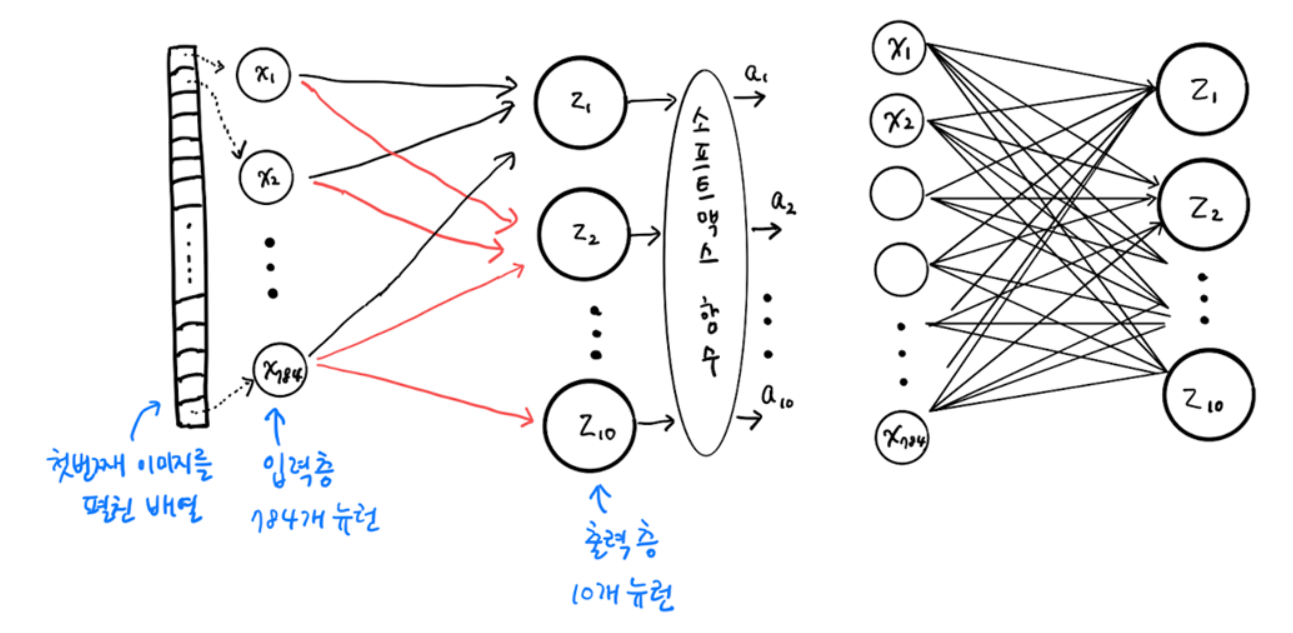

In [ ]:
# 딥러닝 모델은 여러 종류의 "층(layer)"을 쌓아서 만든다.
# 각 층이 데이터를 변환하면서 점점 더 좋은 특징을 학습한다.

# 이번 예제에서는 가장 기본적인 층인 Dense 층을 사용한다.
# Dense 층은 밀집층 또는 완전 연결층(fully connected layer)이라고 부른다.

# Dense 층의 특징
# 이전 층의 모든 입력 값이 다음 층의 모든 뉴런과 연결되어 있다.

# 이번 문제는 패션 아이템 10개를 분류하는 문제이므로
# 출력층에는 10개의 뉴런이 필요하다.

# 다중 분류 문제이기 때문에 활성화 함수는 softmax를 사용한다.
# softmax는 각 클래스에 대한 확률을 계산해 준다.

# 입력 데이터는 28 × 28 이미지이므로
# 784개의 픽셀 값으로 이루어진 1차원 배열이다.

# 이진 분류 문제라면 출력 뉴런은 1개이고
# 활성화 함수로 sigmoid를 사용한다.

# 케라스에서는 첫 번째 층을 만들 때 입력 데이터의 크기를 지정해야 한다.
# 이후에 추가되는 층들은 이전 층의 출력 크기를 자동으로 계산한다.

# 케라스 모델은 보통 Sequential 클래스를 사용하여 만든다.
# Sequential은 층을 순서대로 쌓아가는 방식의 신경망 구조이다.

# 여기서 만들 층은 출력층에 해당한다.
# 패션 아이템 10개를 분류하기 위해 10개의 뉴런을 가진 층을 만든다.

# 케라스의 layers 패키지에는 다양한 종류의 층이 있는데
# 그중 가장 기본적인 층이 Dense 층이다.

# Dense 층의 의미
# 입력 뉴런과 출력 뉴런이 모두 연결된 구조를 의미한다.

# 예를 들어 입력이 784개이고 출력 뉴런이 10개라면
# 모든 입력이 모든 뉴런과 연결된다.

# 따라서 연결되는 가중치의 개수는
# 784 × 10 = 7840 개가 된다.

# 이렇게 모든 뉴런이 서로 연결된 층을
# 완전 연결층(fully connected layer)이라고 부른다.

In [11]:
# 딥러닝 모델에서 사용할 Dense 층 생성
# Dense 층은 입력 뉴런과 출력 뉴런이 모두 연결된 완전 연결층(fully connected layer)이다.

dense = keras.layers.Dense(
    10,                 # 출력 뉴런의 개수 (패션 아이템 10개 클래스)
    activation='softmax',  # 활성화 함수 : softmax → 다중 분류에서 확률을 계산
    input_shape=(784,)     # 입력 데이터의 크기 (28×28 이미지를 펼친 784개의 픽셀)
)

# activation='softmax'
# 출력값을 0~1 사이의 확률로 변환하고
# 모든 클래스 확률의 합이 1이 되도록 만든다.
# 다중 분류 문제에서 사용한다.

# activation='sigmoid'
# 출력값을 0~1 사이 확률로 변환하지만
# 보통 이진 분류(Yes/No 문제)에서 사용한다.

# input_shape=(784,)
# 이 층이 입력으로 받는 데이터의 크기
# 28×28 이미지 → 784개의 픽셀 값으로 이루어진 1차원 배열

# 즉 각 뉴런은 784개의 입력값을 받아 계산을 수행한다.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# 앞에서 만든 Dense 층을 사용하여 인공신경망 모델을 생성

# keras.Sequential 클래스는 층(layer)을 순서대로 쌓아
# 신경망 모델을 만드는 가장 기본적인 방법이다.

# Sequential은 말 그대로 "순차적으로 층을 연결하는 구조"를 의미한다.
# 즉 입력 → 층1 → 층2 → ... → 출력 형태로 데이터가 흐른다.

model = keras.Sequential([dense])

# Sequential 객체를 생성하면서
# 리스트 형태로 층(layer)을 전달한다.

# 여기서는 앞에서 만든 dense 층 하나만 전달했기 때문에
# 구조는 다음과 같은 가장 단순한 신경망이 된다.

# 입력층 (784)
#      ↓
# Dense 층 (출력 뉴런 10개)
#      ↓
# Softmax
#      ↓
# 각 클래스 확률

# 이렇게 만들어진 model 객체가
# 실제로 학습(train)과 예측(predict)을 수행하는 신경망 모델이다.

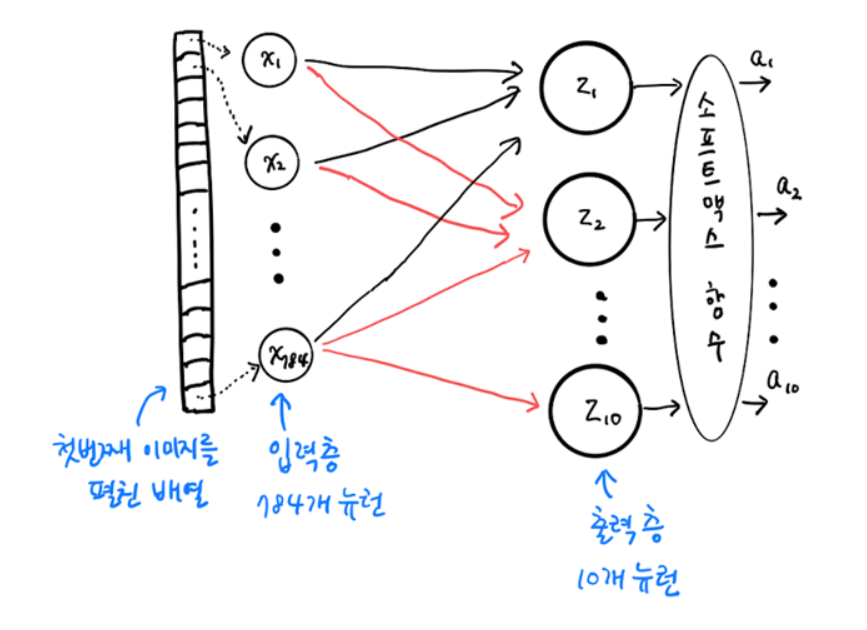

In [13]:
# softmax처럼 뉴런의 선형 계산 결과(z 값)에 적용되는 함수를
# 활성화 함수(activation function)라고 한다.
# 활성화 함수는 뉴런의 출력값을 변환하는 역할을 한다.

# 이제 인공신경망 모델을 학습하기 전에 필요한 설정을 한다.
# (모델 구조 정의 단계가 끝나고, 학습 준비 단계)

############################
# 케라스 모델 훈련 전 설정 단계
############################

# model.compile() 메서드는
# 모델을 어떻게 학습할지 설정하는 단계이다.

# loss : 손실 함수 (모델이 얼마나 틀렸는지 계산하는 함수)
# sparse_categorical_crossentropy
# → 다중 분류 문제에서 사용하는 손실 함수
# → 정답 라벨이 정수 형태일 때 사용 (예: 0,1,2,3,...)

# 참고
# binary_crossentropy
# → 이진 분류 문제에서 사용하는 손실 함수 (Yes/No 문제)

# metrics : 모델 성능을 평가할 지표
# accuracy → 정확도 (맞춘 비율)

model.compile(
    loss='sparse_categorical_crossentropy',  # 다중 분류용 손실 함수
    metrics=['accuracy']                     # 정확도를 평가 지표로 사용
)

# 케라스는 모델을 학습할 때
# 각 epoch마다 손실(loss) 값을 자동으로 기록한다.

# metrics=['accuracy']를 추가하면
# epoch마다 정확도(accuracy)도 함께 기록한다.

# Fashion MNIST 클래스 라벨 의미
# 0 : 티셔츠
# 1 : 바지
# 2 : 스웨터
# 3 : 드레스
# 4 : 코트
# 5 : 샌달
# 6 : 셔츠
# 7 : 스니커즈
# 8 : 가방
# 9 : 앵클부츠

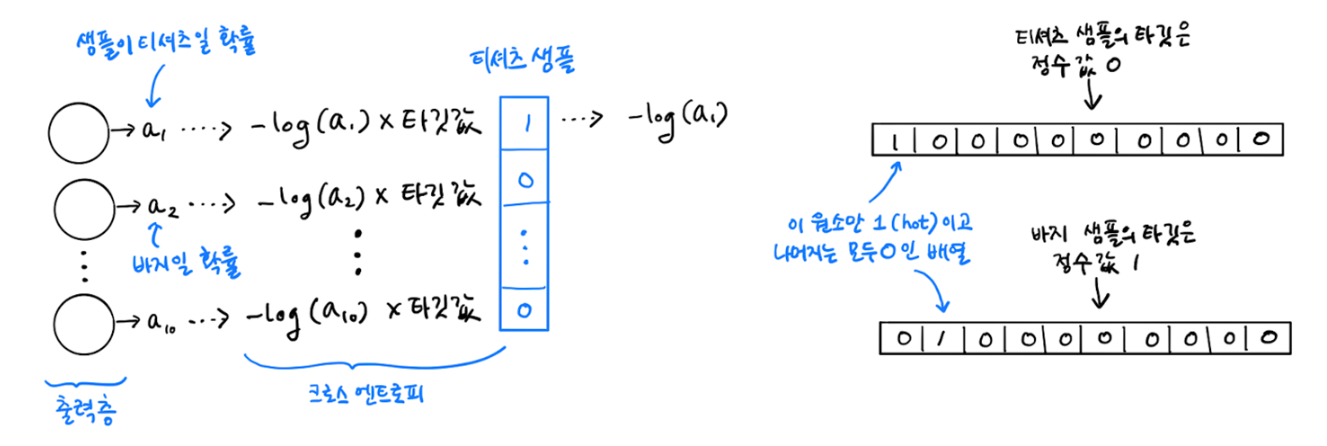

In [14]:
# train_target 배열의 처음 10개 값을 출력하여
# 정답(label) 데이터가 어떤 형태인지 확인한다.
print(train_target[:10])

# Fashion MNIST 데이터의 타깃은
# 각 이미지가 어떤 패션 아이템인지 나타내는 정수값으로 저장되어 있다.

# 예를 들어 출력이 다음과 같이 나타날 수 있다.
# [9 0 0 3 0 2 7 2 5 5]

# 이 숫자는 각 이미지의 클래스 번호를 의미한다.
# 즉 "정답 클래스의 인덱스(index)"가 저장되어 있다.

# 클래스 번호 의미
# 0 : 티셔츠
# 1 : 바지
# 2 : 스웨터
# 3 : 드레스
# 4 : 코트
# 5 : 샌달
# 6 : 셔츠
# 7 : 스니커즈
# 8 : 가방
# 9 : 앵클부츠

# 이렇게 정수 형태로 저장된 타깃을
# "정수 인코딩된 라벨(integer label)"이라고 한다.

# 케라스에서 loss='sparse_categorical_crossentropy'를 사용하면
# 원-핫 인코딩을 직접 만들지 않아도
# 내부적으로 정수 라벨을 처리해 다중 분류 학습을 수행할 수 있다.

############################
# 모델 컴파일 설정 단계 종료
############################

[7 3 5 8 6 9 3 3 9 9]


In [15]:
model.fit(train_scaled, train_target, epochs=5)
# 훈련시작 (에포크 5로 5번 훈련 중....) 25초 정도 걸림

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7370 - loss: 0.7853
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8346 - loss: 0.4845
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8452 - loss: 0.4564
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8504 - loss: 0.4425
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8537 - loss: 0.4337


In [16]:
# 모델을 학습하면 케라스는 epoch마다 다음 정보를 출력한다.
# - 학습에 걸린 시간
# - 정확도(accuracy)
# - 손실값(loss)

# 예를 들어 정확도가 0.85라면
# 약 85% 정도의 데이터를 맞췄다는 의미이다.

# 학습이 끝난 뒤에는
# model.evaluate() 메서드를 사용하여 모델의 성능을 평가할 수 있다.

# evaluate()는 새로운 데이터(검증 세트 또는 테스트 세트)를 이용해
# 모델이 얼마나 잘 예측하는지 확인하는 함수이다.

model.evaluate(val_scaled, val_target)

# val_scaled : 검증용 입력 데이터 (이미지 픽셀 값)
# val_target : 검증용 정답 라벨

# 실행 결과로 다음 두 가지 값이 반환된다.
# 1️⃣ loss     : 손실값 (모델이 얼마나 틀렸는지)
# 2️⃣ accuracy : 정확도 (맞춘 비율)

# 예를 들어 결과가
# [0.40, 0.8537] 이라면

# loss = 0.40
# accuracy = 0.8537 → 약 85.37% 정확도

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8462 - loss: 0.4364


[0.4444445073604584, 0.8458333611488342]

In [ ]:
# 사이킷런과 케라스 모델 비교

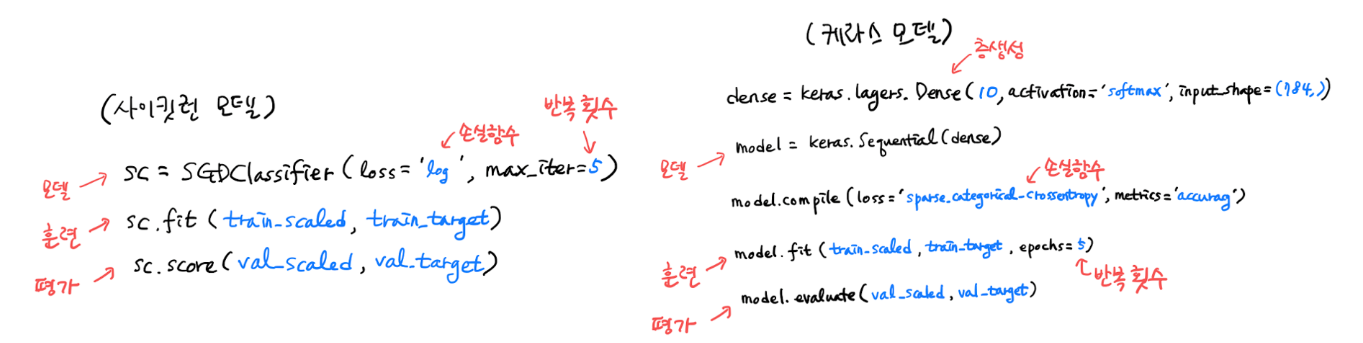